In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_csv('homeprices.csv')
df.head(7)

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [6]:
#df.info()

In [5]:
df.isna().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [7]:
most_f = df['bedrooms'].mode()

In [9]:
avg = df['bedrooms'].mean()

In [11]:
df = df.fillna({'bedrooms': 4.0})

In [28]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


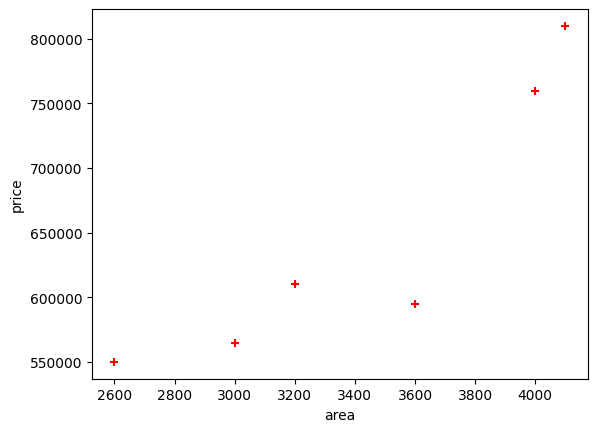

In [15]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area, df.price, color='red',marker='+')
plt.show()

In [13]:
X = df.drop('price', axis=1) 
y = df['price']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
linear_reg = linear_model.LinearRegression()
linear_reg.fit(X, y)

LinearRegression()

In [22]:
pred = linear_reg.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

In [38]:
dataf = pd.DataFrame({ 'actual_price': y_test, 'predicted': pred})

In [39]:
dataf

,actual_price,predicted
0,550000,518217.632976
1,565000,602590.079374


In [29]:
reg = linear_model.LinearRegression()
reg.fit(df.drop('price',axis='columns'),df.price)

LinearRegression()

In [45]:
reg.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [46]:
reg.intercept_

np.float64(221323.0018654039)

In [42]:
p1 = reg.predict([[3000, 3, 40]])
p1

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

In [47]:
p2 = reg.predict([[2500, 4, 5]])
p2

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([578876.03748933])

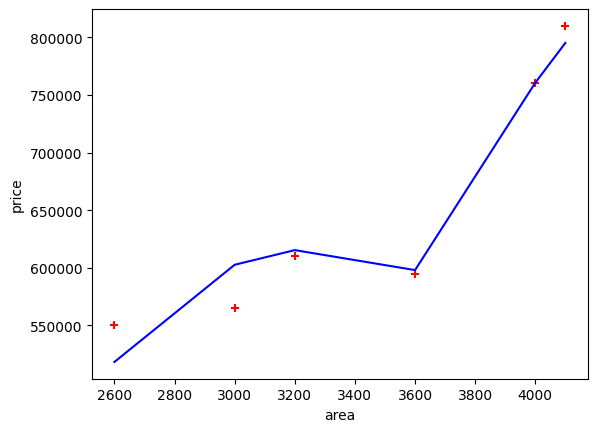

In [51]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area, df.price, color='red', marker='+')
plt.plot(df.area, linear_reg.predict(df[['area', 'bedrooms', 'age']]), color='blue')
plt.show()